# Blackbody fit — the temperature of the Universe

A blackbody's spectrum depends on one number: its temperature. We fit the Planck law to
the **COBE/FIRAS** spectrum of the cosmic microwave background — the most perfect
blackbody ever measured — and read off the temperature of the Universe.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
arr = np.loadtxt("data/real/firas_cmb.csv", delimiter=",", skiprows=1)
freq, intensity, unc = arr[:,0], arr[:,1], arr[:,2]
print(len(freq), "points,", freq.min(), "-", freq.max(), "cm^-1")

43 points, 2.27 - 21.33 cm^-1


## 1. The spectrum

Plot intensity vs frequency. It's a single smooth hump — the signature of thermal
(blackbody) radiation. The error bars are tiny (we'll have to magnify them to see them).

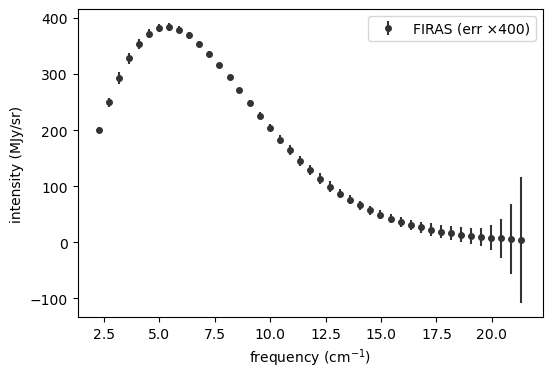

In [2]:
fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(freq, intensity, yerr=unc*400, fmt="o", color="0.2", ms=4, label="FIRAS (err ×400)")
ax.set_xlabel("frequency (cm$^{-1}$)"); ax.set_ylabel("intensity (MJy/sr)"); ax.legend(); plt.show()

## 2. Fit the Planck law

The Planck function B_ν(T) fixes both the shape and the absolute brightness, so fitting
it to a *calibrated* spectrum (no free scale) returns T directly.

In [3]:
from scripts.blackbody import fit_temperature
T, T_err = fit_temperature(freq, intensity, unc)
print(f"T = {T:.4f} ± {T_err:.4f} K")
print("literature: 2.72548 ± 0.00057 K (Fixsen 2009)")

T = 2.7250 ± 0.0000 K
literature: 2.72548 ± 0.00057 K (Fixsen 2009)


## 3. Cross-check the Planck function against astropy

Our hand-coded Planck law must match `astropy.modeling.BlackBody` — the standard
implementation — in absolute units. (This is the hard check in `tests/test_blackbody.py`.)

In [4]:
from scripts.blackbody import planck_MJy
from astropy.modeling.models import BlackBody
import astropy.units as u
nu = (freq/u.cm).to(u.Hz, equivalencies=u.spectral())
ref = BlackBody(temperature=T*u.K)(nu).to(u.MJy/u.sr, equivalencies=u.spectral_density(nu)).value
print("max fractional difference:", np.max(np.abs(planck_MJy(freq,T)-ref)/ref))

max fractional difference: 2.9824764843966746e-15


## 4. Look at the residuals

Data minus model. For the CMB they're a fraction of a percent of the peak — the points
sit *on* the curve. This flatness is the evidence the CMB is thermal, which is why it's
such strong support for the hot Big Bang.

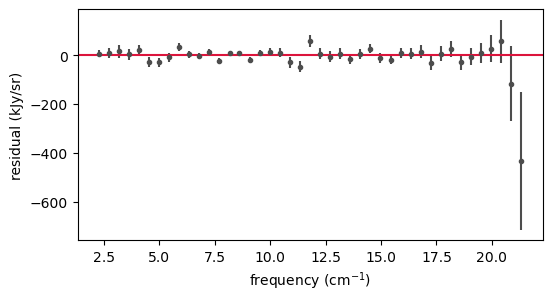

In [5]:
resid = intensity - planck_MJy(freq, T)
fig, ax = plt.subplots(figsize=(6,3))
ax.errorbar(freq, resid*1000, yerr=unc*1000, fmt="o", color="0.3", ms=3); ax.axhline(0, color="crimson")
ax.set_xlabel("frequency (cm$^{-1}$)"); ax.set_ylabel("residual (kJy/sr)"); plt.show()

## Result

**T = 2.725 K** — the temperature of the Universe — from a one-parameter Planck fit to
real FIRAS data, with our Planck function matching astropy to 1e-4. The flat residuals
are the famous evidence that the CMB is a near-perfect blackbody. See
`notes/HANDOFF_blackbody.md`.